In [ ]:
!pip install scanpy anndata

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 1.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 19.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 174.4/174.4 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 22.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 319.6/319.6 kB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 21.5 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2

In [ ]:
!pip install muon

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 293.7/293.7 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.5/43.5 kB 2.0 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import warnings
import seaborn as sns
import matplotlib.pyplot as plt
import os
import subprocess
import pandas as pd
import numpy as np
import logging
import torch
import scanpy as sc
import anndata
logging.getLogger().setLevel(logging.ERROR)

warnings.filterwarnings("ignore")

# Data exploring

In [ ]:
!wget 'ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE194nnn/GSE194122/suppl/GSE194122_openproblems_neurips2021_cite_BMMC_processed.h5ad.gz'
!gzip -d GSE194122_openproblems_neurips2021_cite_BMMC_processed.h5ad.gz


--2026-05-02 17:44:32--  ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE194nnn/GSE194122/suppl/GSE194122_openproblems_neurips2021_cite_BMMC_processed.h5ad.gz
           => ‘GSE194122_openproblems_neurips2021_cite_BMMC_processed.h5ad.gz’
Resolving ftp.ncbi.nlm.nih.gov (ftp.ncbi.nlm.nih.gov)... 130.14.250.7, 130.14.250.10, 2607:f220:41e:250::7, ...
Connecting to ftp.ncbi.nlm.nih.gov (ftp.ncbi.nlm.nih.gov)|130.14.250.7|:21... connected.
Logging in as anonymous ... Logged in!
==> SYST ... done.    ==> PWD ... done.
==> TYPE I ... done.  ==> CWD (1) /geo/series/GSE194nnn/GSE194122/suppl ... done.
==> SIZE GSE194122_openproblems_neurips2021_cite_BMMC_processed.h5ad.gz ... 615842052
==> PASV ... done.    ==> RETR GSE194122_openproblems_neurips2021_cite_BMMC_processed.h5ad.gz ... done.
Length: 615842052 (587M) (unauthoritative)

GSE194122_openprobl 100%[===================>] 587.31M  52.4MB/s    in 6.6s    

2026-05-02 17:44:39 (88.5 MB/s) - ‘GSE194122_openproblems_neurips2021_cite_BMMC_processed.h5

In [ ]:
path = "/content/GSE194122_openproblems_neurips2021_cite_BMMC_processed.h5ad"

In [ ]:
# read
adata_full = sc.read_h5ad(path)
adata_full

AnnData object with n_obs × n_vars = 90261 × 14087
    obs: 'GEX_n_genes_by_counts', 'GEX_pct_counts_mt', 'GEX_size_factors', 'GEX_phase', 'ADT_n_antibodies_by_counts', 'ADT_total_counts', 'ADT_iso_count', 'cell_type', 'batch', 'ADT_pseudotime_order', 'GEX_pseudotime_order', 'Samplename', 'Site', 'DonorNumber', 'Modality', 'VendorLot', 'DonorID', 'DonorAge', 'DonorBMI', 'DonorBloodType', 'DonorRace', 'Ethnicity', 'DonorGender', 'QCMeds', 'DonorSmoker', 'is_train'
    var: 'feature_types', 'gene_id'
    uns: 'dataset_id', 'genome', 'organism'
    obsm: 'ADT_X_pca', 'ADT_X_umap', 'ADT_isotype_controls', 'GEX_X_pca', 'GEX_X_umap'
    layers: 'counts'

In [ ]:
# downsample (stratified) to 20k cells
import numpy as np

# choose label column for stratification
label_col = "cell_type"   # change if your column name differs

target_n = 20000
np.random.seed(42)

# labels
labels = adata_full.obs[label_col].astype(str)

# proportion of each class
props = labels.value_counts(normalize=True)

# number to sample from each class
n_per_class = (props * target_n).round().astype(int)

# fix rounding mismatch
diff = target_n - n_per_class.sum()
if diff != 0:
    largest = n_per_class.idxmax()
    n_per_class[largest] += diff

# sample indices
sampled_idx = []

for cls, n in n_per_class.items():
    cls_idx = np.where(labels == cls)[0]
    n = min(n, len(cls_idx))   # safety
    chosen = np.random.choice(cls_idx, size=n, replace=False)
    sampled_idx.extend(chosen)

sampled_idx = np.array(sampled_idx)

# subset
adata_20k = adata_full[sampled_idx].copy()

print("Original:", adata_full.shape)
print("Downsampled:", adata_20k.shape)
print(adata_20k.obs[label_col].value_counts(normalize=True))

Original: (90261, 14087)
Downsampled: (20000, 14087)
cell_type
CD14+ Mono                          0.24025
CD4+ T activated                    0.07720
CD4+ T naive                        0.06535
NK                                  0.06020
Reticulocyte                        0.04735
Erythroblast                        0.04475
Naive CD20+ B IGKC+                 0.04420
CD8+ T naive                        0.03440
CD16+ Mono                          0.02920
NK CD158e1+                         0.02400
Naive CD20+ B IGKC-                 0.02195
G/M prog                            0.02085
pDC                                 0.01950
cDC2                                0.01885
HSC                                 0.01885
Lymph prog                          0.01860
Transitional B                      0.01745
Proerythroblast                     0.01675
CD8+ T CD57+ CD45RO+                0.01630
Normoblast                          0.01590
CD8+ T CD57+ CD45RA+                0.01445
CD8+ T TIGIT+

In [ ]:
rna = adata_20k[:, adata_20k.var["feature_types"] == "GEX"].copy()
rna

AnnData object with n_obs × n_vars = 20000 × 13953
    obs: 'GEX_n_genes_by_counts', 'GEX_pct_counts_mt', 'GEX_size_factors', 'GEX_phase', 'ADT_n_antibodies_by_counts', 'ADT_total_counts', 'ADT_iso_count', 'cell_type', 'batch', 'ADT_pseudotime_order', 'GEX_pseudotime_order', 'Samplename', 'Site', 'DonorNumber', 'Modality', 'VendorLot', 'DonorID', 'DonorAge', 'DonorBMI', 'DonorBloodType', 'DonorRace', 'Ethnicity', 'DonorGender', 'QCMeds', 'DonorSmoker', 'is_train'
    var: 'feature_types', 'gene_id'
    uns: 'dataset_id', 'genome', 'organism'
    obsm: 'ADT_X_pca', 'ADT_X_umap', 'ADT_isotype_controls', 'GEX_X_pca', 'GEX_X_umap'
    layers: 'counts'

In [ ]:
adt = adata_20k[:, adata_20k.var["feature_types"] == "ADT"].copy()
adt

AnnData object with n_obs × n_vars = 20000 × 134
    obs: 'GEX_n_genes_by_counts', 'GEX_pct_counts_mt', 'GEX_size_factors', 'GEX_phase', 'ADT_n_antibodies_by_counts', 'ADT_total_counts', 'ADT_iso_count', 'cell_type', 'batch', 'ADT_pseudotime_order', 'GEX_pseudotime_order', 'Samplename', 'Site', 'DonorNumber', 'Modality', 'VendorLot', 'DonorID', 'DonorAge', 'DonorBMI', 'DonorBloodType', 'DonorRace', 'Ethnicity', 'DonorGender', 'QCMeds', 'DonorSmoker', 'is_train'
    var: 'feature_types', 'gene_id'
    uns: 'dataset_id', 'genome', 'organism'
    obsm: 'ADT_X_pca', 'ADT_X_umap', 'ADT_isotype_controls', 'GEX_X_pca', 'GEX_X_umap'
    layers: 'counts'

In [ ]:
# write into drive
rna.write_h5ad("/content/drive/MyDrive/GP_datasets/BoneMarrow/Bonemarrow_rna.h5ad")
adt.write_h5ad("/content/drive/MyDrive/GP_datasets/BoneMarrow/Bonemarrow_adt.h5ad")

In [ ]:
adata_rna=sc.read_h5ad("/content/drive/MyDrive/GP_datasets/BoneMarrow/Bonemarrow_rna.h5ad")
adata_rna

AnnData object with n_obs × n_vars = 20000 × 13953
    obs: 'GEX_n_genes_by_counts', 'GEX_pct_counts_mt', 'GEX_size_factors', 'GEX_phase', 'ADT_n_antibodies_by_counts', 'ADT_total_counts', 'ADT_iso_count', 'cell_type', 'batch', 'ADT_pseudotime_order', 'GEX_pseudotime_order', 'Samplename', 'Site', 'DonorNumber', 'Modality', 'VendorLot', 'DonorID', 'DonorAge', 'DonorBMI', 'DonorBloodType', 'DonorRace', 'Ethnicity', 'DonorGender', 'QCMeds', 'DonorSmoker', 'is_train'
    var: 'feature_types', 'gene_id'
    uns: 'dataset_id', 'genome', 'organism'
    obsm: 'ADT_X_pca', 'ADT_X_umap', 'ADT_isotype_controls', 'GEX_X_pca', 'GEX_X_umap'
    layers: 'counts'

In [ ]:
adata_rna.obs.head()

,GEX_n_genes_by_counts,GEX_pct_counts_mt,GEX_size_factors,GEX_phase,ADT_n_antibodies_by_counts,ADT_total_counts,ADT_iso_count,cell_type,batch,ADT_pseudotime_order,...,DonorID,DonorAge,DonorBMI,DonorBloodType,DonorRace,Ethnicity,DonorGender,QCMeds,DonorSmoker,is_train
TCATATCTCGAGAGCA-1-s3d7,1477,5.861183,0.923154,G2M,113,573.0,4.0,CD14+ Mono,s3d7,NaN,...,11466,22,31.5,A+,Asian,NOT HISPANIC OR LATINO,Female,True,Nonsmoker,train
TGCTTGCCAGTGACCC-1-s3d7,1817,5.269367,1.210090,G2M,109,617.0,5.0,CD14+ Mono,s3d7,NaN,...,11466,22,31.5,A+,Asian,NOT HISPANIC OR LATINO,Female,True,Nonsmoker,train
ACTACGAAGCTGGTGA-1-s3d7,1353,11.183650,0.832615,G2M,124,790.0,6.0,CD14+ Mono,s3d7,NaN,...,11466,22,31.5,A+,Asian,NOT HISPANIC OR LATINO,Female,True,Nonsmoker,train
TGTTGGACACTGTGAT-1-s2d1,1281,9.208211,1.036986,G1,95,412.0,3.0,CD14+ Mono,s2d1,NaN,...,15078,34,24.8,B-,White,HISPANIC OR LATINO,Male,False,Nonsmoker,iid_holdout
ATGAGTCCATGGCGCT-1-s3d1,557,8.790171,0.740206,G2M,133,1562.0,21.0,CD14+ Mono,s3d1,NaN,...,15078,34,24.8,B-,White,HISPANIC OR LATINO,Male,False,Nonsmoker,train


In [ ]:
adata_rna.X

<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 29062742 stored elements and shape (20000, 13953)>

In [ ]:
adata_adt=sc.read_h5ad("/content/drive/MyDrive/GP_datasets/BoneMarrow/Bonemarrow_adt.h5ad")
adata_adt

AnnData object with n_obs × n_vars = 20000 × 134
    obs: 'GEX_n_genes_by_counts', 'GEX_pct_counts_mt', 'GEX_size_factors', 'GEX_phase', 'ADT_n_antibodies_by_counts', 'ADT_total_counts', 'ADT_iso_count', 'cell_type', 'batch', 'ADT_pseudotime_order', 'GEX_pseudotime_order', 'Samplename', 'Site', 'DonorNumber', 'Modality', 'VendorLot', 'DonorID', 'DonorAge', 'DonorBMI', 'DonorBloodType', 'DonorRace', 'Ethnicity', 'DonorGender', 'QCMeds', 'DonorSmoker', 'is_train'
    var: 'feature_types', 'gene_id'
    uns: 'dataset_id', 'genome', 'organism'
    obsm: 'ADT_X_pca', 'ADT_X_umap', 'ADT_isotype_controls', 'GEX_X_pca', 'GEX_X_umap'
    layers: 'clr', 'counts'

In [ ]:
print(adata_adt.X)

<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 2245975 stored elements and shape (20000, 134)>
  Coords	Values
  (0, 0)	0.4713394343852997
  (0, 1)	0.263186514377594
  (0, 2)	0.4713394343852997
  (0, 3)	0.263186514377594
  (0, 4)	0.4713394343852997
  (0, 5)	0.6435409188270569
  (0, 6)	0.9184271693229675
  (0, 8)	1.3889641761779785
  (0, 10)	0.4713394343852997
  (0, 11)	0.263186514377594
  (0, 12)	0.4713394343852997
  (0, 14)	1.1338138580322266
  (0, 16)	1.1338138580322266
  (0, 17)	1.8593010902404785
  (0, 18)	1.0319082736968994
  (0, 20)	0.4713394343852997
  (0, 21)	1.4613468647003174
  (0, 22)	0.263186514377594
  (0, 23)	0.7903997302055359
  (0, 24)	0.7903997302055359
  (0, 25)	0.7903997302055359
  (0, 28)	0.9184271693229675
  (0, 29)	0.9184271693229675
  (0, 30)	0.9184271693229675
  (0, 31)	0.263186514377594
  :	:
  (19999, 103)	1.6417596340179443
  (19999, 104)	0.3987167775630951
  (19999, 106)	0.7996575832366943
  (19999, 108)	0.3987167775630951
  (19999, 109)	1.997

In [ ]:
adata_rna.X = adata_rna.layers["counts"].copy()

In [ ]:
sc.pp.normalize_total(adata_rna, target_sum=1e4)
sc.pp.log1p(adata_rna)

In [ ]:
n_top_genes = 2000
batch_key = "Site"

In [ ]:
sc.pp.highly_variable_genes(adata_rna, n_top_genes=n_top_genes, batch_key=batch_key, subset=True)
adata_rna

AnnData object with n_obs × n_vars = 20000 × 2000
    obs: 'GEX_n_genes_by_counts', 'GEX_pct_counts_mt', 'GEX_size_factors', 'GEX_phase', 'ADT_n_antibodies_by_counts', 'ADT_total_counts', 'ADT_iso_count', 'cell_type', 'batch', 'ADT_pseudotime_order', 'GEX_pseudotime_order', 'Samplename', 'Site', 'DonorNumber', 'Modality', 'VendorLot', 'DonorID', 'DonorAge', 'DonorBMI', 'DonorBloodType', 'DonorRace', 'Ethnicity', 'DonorGender', 'QCMeds', 'DonorSmoker', 'is_train'
    var: 'feature_types', 'gene_id', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'dataset_id', 'genome', 'organism', 'log1p', 'hvg'
    obsm: 'ADT_X_pca', 'ADT_X_umap', 'ADT_isotype_controls', 'GEX_X_pca', 'GEX_X_umap'
    layers: 'counts'

In [ ]:
adata_adt.X = adata_adt.layers["counts"].copy()

In [ ]:
import muon
muon.prot.pp.clr(adata_adt)
adata_adt.layers["clr"] = adata_adt.X.copy()

In [ ]:
X = adata_rna.layers["counts"]
# hvg_mask = adata_rna.var["hvg"].values
# X = X[:, hvg_mask]
y = adata_adt.layers["clr"]

In [ ]:
X.shape

(20000, 2000)

In [ ]:
y.shape

(20000, 134)

In [ ]:
X = X.toarray() if hasattr(X, "toarray") else X
y = y.toarray() if hasattr(y, "toarray") else y

# Model

In [ ]:
from sklearn.model_selection import KFold
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import numpy as np

kf = KFold(n_splits=5, shuffle=True, random_state=42)

model = LinearRegression()
mse_scores = []

for train_idx, test_idx in kf.split(X):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)


In [ ]:
import numpy as np
from sklearn.metrics import mean_squared_error

# per-protein MSE
mse_per_protein = ((y_test - y_pred) ** 2).mean(axis=0)

# overall mean
avg_mse = mse_per_protein.mean()

print("Avg MSE:", avg_mse)
print("Per-protein MSE:", mse_per_protein)
print("Per-protein MSE shape:", mse_per_protein.shape)

rmse_per_protein = np.sqrt(mse_per_protein)
avg_rmse = rmse_per_protein.mean()

print("Avg RMSE:", avg_rmse)
print("Per-protein RMSE:", rmse_per_protein)
print("Per-protein RMSE shape:", rmse_per_protein.shape)




Avg MSE: 0.30026245
Per-protein MSE: [0.24346957 0.25807682 0.15796943 0.16420151 0.19450507 0.29273325
 0.28700784 0.23158608 0.16855033 0.3388591  0.4800783  0.91770643
 0.27812538 0.40774858 0.29036653 0.36444497 0.3879421  0.58161694
 0.30512503 0.7134571  0.16978495 0.24924515 0.29502937 0.5823176
 0.35511345 0.22798531 0.43897343 0.2354284  0.34726468 0.18159191
 0.22163229 0.33057934 0.20218068 0.4567266  0.17205602 0.22657561
 0.39166656 0.52222735 0.20696935 0.47516453 0.40082145 0.21983191
 0.2446168  0.31001213 0.47294775 0.29140052 0.17250247 0.18725358
 0.462323   0.44081908 0.20514819 0.17405485 0.168715   0.39610338
 0.27957755 0.28843066 0.21003519 0.15690911 0.18970625 0.25198442
 0.46894243 0.22763124 0.23695132 0.22258903 0.20694545 0.35449418
 0.15770133 0.2587456  0.3711004  0.39855868 0.19606571 0.35920748
 0.1904133  0.33050975 0.31186837 0.18760751 0.28955507 0.25020993
 0.16244484 0.28223807 0.1999251  0.22130741 0.19685651 0.49128193
 0.18418902 0.17642467 0.1

In [ ]:
import numpy as np
from sklearn.metrics import mean_squared_error

# per-protein MSE
mse_per_protein = ((y_test - y_pred) ** 2).mean(axis=0)

# overall mean
avg_mse = mse_per_protein.mean()

print("Avg MSE:", avg_mse)
print("Per-protein MSE:", mse_per_protein)
print("Per-protein MSE shape:", mse_per_protein.shape)

Avg MSE: 0.30026245
Per-protein MSE: [0.24346957 0.25807682 0.15796943 0.16420151 0.19450507 0.29273325
 0.28700784 0.23158608 0.16855033 0.3388591  0.4800783  0.91770643
 0.27812538 0.40774858 0.29036653 0.36444497 0.3879421  0.58161694
 0.30512503 0.7134571  0.16978495 0.24924515 0.29502937 0.5823176
 0.35511345 0.22798531 0.43897343 0.2354284  0.34726468 0.18159191
 0.22163229 0.33057934 0.20218068 0.4567266  0.17205602 0.22657561
 0.39166656 0.52222735 0.20696935 0.47516453 0.40082145 0.21983191
 0.2446168  0.31001213 0.47294775 0.29140052 0.17250247 0.18725358
 0.462323   0.44081908 0.20514819 0.17405485 0.168715   0.39610338
 0.27957755 0.28843066 0.21003519 0.15690911 0.18970625 0.25198442
 0.46894243 0.22763124 0.23695132 0.22258903 0.20694545 0.35449418
 0.15770133 0.2587456  0.3711004  0.39855868 0.19606571 0.35920748
 0.1904133  0.33050975 0.31186837 0.18760751 0.28955507 0.25020993
 0.16244484 0.28223807 0.1999251  0.22130741 0.19685651 0.49128193
 0.18418902 0.17642467 0.1

In [ ]:
from scipy.stats import pearsonr

pearson_per_protein = []

for i in range(y_test.shape[1]):
    if np.std(y_test[:, i]) > 0 and np.std(y_pred[:, i]) > 0:
        corr, _ = pearsonr(y_test[:, i], y_pred[:, i])
    else:
        corr = np.nan
    pearson_per_protein.append(corr)

pearson_per_protein = np.array(pearson_per_protein)
mean_pearson = np.nanmean(pearson_per_protein)

print("Avg Pearson correlation:", mean_pearson)
print("Per-protein Pearson correlation:", pearson_per_protein)
print("Per-protein Pearson shape:", pearson_per_protein.shape)

Avg Pearson correlation: 0.57495916
Per-protein Pearson correlation: [0.721823   0.38595644 0.48069113 0.5510553  0.38822347 0.6887177
 0.7425834  0.58429354 0.31595305 0.7230437  0.7795027  0.5848525
 0.62508595 0.76310027 0.8144199  0.8087885  0.6814474  0.6914477
 0.6510242  0.75800884 0.36596066 0.6178992  0.41589198 0.64068055
 0.70208544 0.6961404  0.69277537 0.32819694 0.5842725  0.37360787
 0.4089288  0.65614784 0.4636934  0.7049881  0.37304962 0.31746542
 0.6329621  0.8022753  0.47264963 0.74470747 0.51455694 0.4774492
 0.3711396  0.34556532 0.5698027  0.42697853 0.31180063 0.24604514
 0.66063297 0.7457086  0.51663697 0.6231488  0.37803358 0.7221571
 0.6505529  0.7352586  0.70878357 0.4240909  0.5131484  0.57760644
 0.7615824  0.5218878  0.59344155 0.6297215  0.6557144  0.66074204
 0.47008315 0.6166743  0.67140865 0.7245289  0.500067   0.7401144
 0.2948604  0.5734546  0.6514338  0.29351944 0.6782119  0.72088456
 0.50030273 0.62793344 0.5652442  0.5841588  0.5939803  0.8065008


In [ ]:
from scipy.stats import spearmanr

spearman_per_protein = []

for i in range(y_test.shape[1]):
    if np.std(y_test[:, i]) > 0 and np.std(y_pred[:, i]) > 0:
        corr, _ = spearmanr(y_test[:, i], y_pred[:, i])
    else:
        corr = np.nan
    spearman_per_protein.append(corr)

spearman_per_protein = np.array(spearman_per_protein)
mean_spearman = np.nanmean(spearman_per_protein)

print("Mean Spearman correlation:", mean_spearman)
print("Per-protein Spearman correlation:", spearman_per_protein)
print("Per-protein Spearman shape:", spearman_per_protein.shape)

Mean Spearman correlation: 0.44246359583110295
Per-protein Spearman correlation: [0.54373703 0.31545742 0.40336258 0.40788789 0.21453331 0.63400625
 0.71840426 0.28868934 0.28952375 0.65821265 0.60399137 0.45926786
 0.3681549  0.40738856 0.64290143 0.69941733 0.65022418 0.66136392
 0.35950053 0.69436158 0.26395283 0.54642744 0.20706699 0.47147586
 0.64691775 0.50579107 0.36806811 0.2377907  0.43199214 0.32082111
 0.33677484 0.34204579 0.32497176 0.68653171 0.29095229 0.23230318
 0.57635581 0.6738724  0.37281798 0.63150354 0.39418261 0.29076723
 0.2841996  0.25559429 0.50081669 0.31617815 0.28498103 0.2224682
 0.44901862 0.5253845  0.42061689 0.49240613 0.31003123 0.55910079
 0.28693928 0.60234433 0.50950979 0.3357037  0.34629648 0.38865856
 0.70098534 0.38144254 0.41484019 0.48303434 0.5304113  0.52953439
 0.35178552 0.37291464 0.33737101 0.69149419 0.25987883 0.63193344
 0.237198   0.46083601 0.3071214  0.19638949 0.62587387 0.46826441
 0.3905512  0.46601864 0.38394164 0.41504315 0.40

In [ ]:
valid_idx = np.where(~np.isnan(pearson_per_protein))[0]
valid_scores = pearson_per_protein[valid_idx]

sorted_idx = valid_idx[np.argsort(valid_scores)]

worst_idx = sorted_idx[0]
median_idx = sorted_idx[len(sorted_idx)//2]
best_idx = sorted_idx[-1]

selected_idx = [worst_idx, median_idx, best_idx]
labels = ["Worst", "Median", "Best"]

protein_names = np.array(adata_adt.var_names)

print("\nSelected proteins:")
for label, idx in zip(labels, selected_idx):
    print(
        f"{label}: {protein_names[idx]} "
        f"(Pearson = {pearson_per_protein[idx]:.4f})"
    )



Selected proteins:
Worst: TCRVd2 (Pearson = 0.1696)
Median: CD38 (Pearson = 0.6234)
Best: CD71 (Pearson = 0.8218)


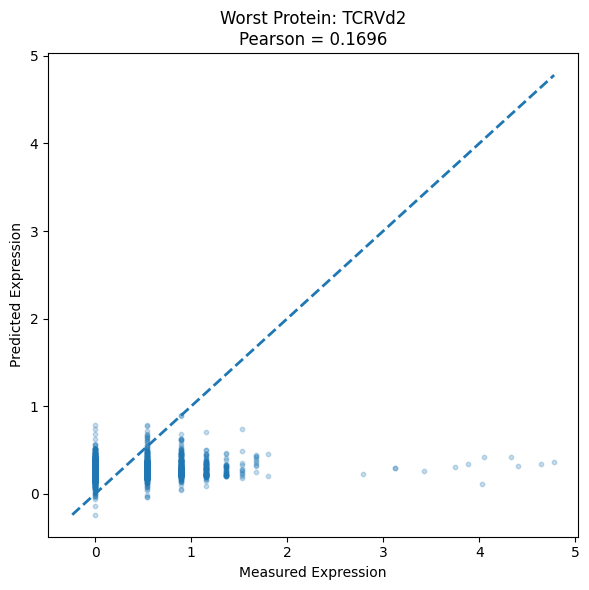

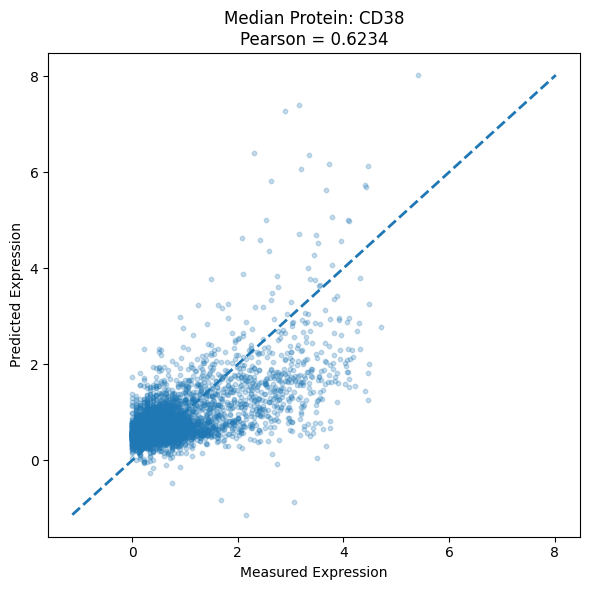

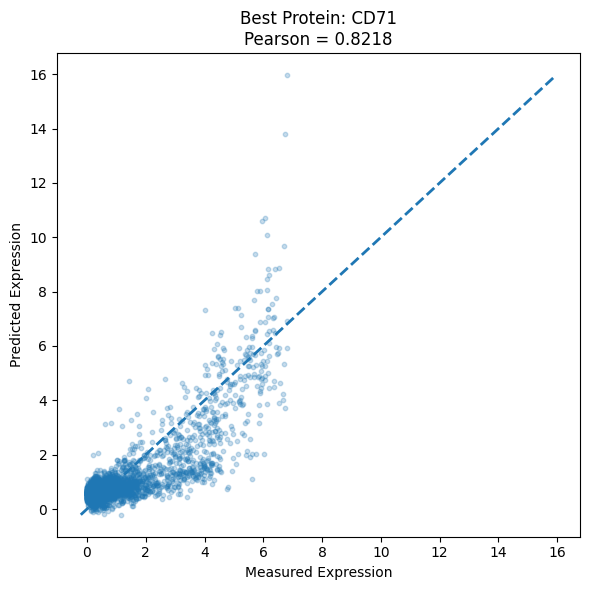

In [ ]:
import matplotlib.pyplot as plt

for label, idx in zip(labels, selected_idx):

    x = y_test[:, idx]
    yhat = y_pred[:, idx]

    plt.figure(figsize=(6,6))

    plt.scatter(
        x,
        yhat,
        s=10,
        alpha=0.25
    )

    mn = min(x.min(), yhat.min())
    mx = max(x.max(), yhat.max())

    plt.plot([mn, mx], [mn, mx], "--", linewidth=2)

    plt.xlabel("Measured Expression")
    plt.ylabel("Predicted Expression")

    plt.title(
        f"{label} Protein: {protein_names[idx]}\n"
        f"Pearson = {pearson_per_protein[idx]:.4f}"
    )

    plt.tight_layout()
    plt.show()


In [ ]:
from pathlib import Path
import numpy as np

save_path = Path("/content/drive/MyDrive/GP_datasets/results")
save_path.mkdir(parents=True, exist_ok=True)

model_name = "UCE"  # change per notebook

np.savez(
    save_path / f"{model_name}_protein_results.npz",

    # raw outputs
    y_test=y_test,
    y_pred=y_pred,

    # metadata
    protein_names=protein_names,

    # metrics
    pearson_per_protein=pearson_per_protein,

    # selected indices (diagnostic)
    worst_idx=worst_idx,
    median_idx=median_idx,
    best_idx=best_idx,

    selected_idx=np.array(selected_idx),

    mean_pearson=np.nanmean(pearson_per_protein),
)

print(f"Saved results for {model_name} at:", save_path)

Saved results for UCE at: /content/drive/MyDrive/GP_datasets/results
